# FraudShield X — Credit Card Fraud Detection

## Data Exploration & Analysis

This notebook performs exploratory data analysis on the credit card transaction dataset used by FraudShield X.

### Objectives

- Understand the structure of the dataset
- Identify missing and duplicate records
- Analyze transaction distributions
- Study fraud vs genuine transactions
- Identify class imbalance
- Explore transaction amount and time patterns
- Prepare the dataset for feature engineering and machine learning

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

DATA_PATH = "../../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully!
Rows: 284,807
Columns: 31


## 1. Dataset Overview

First, we inspect the available columns and preview the first few transactions.

In [3]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Dataset Information

We examine the data types, number of non-null values, and overall memory usage.

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 3. Missing Value Analysis

Missing values can affect machine learning models, so we check every feature for null values.

In [6]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


## 4. Duplicate Transaction Analysis

Duplicate records can introduce bias into model training. We therefore check for duplicate rows.

In [7]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 1,081


## 5. Fraud vs Genuine Transactions

The `Class` column is the target variable.

- `0` represents a genuine transaction
- `1` represents a fraudulent transaction

We analyze the distribution of both classes to identify potential class imbalance.

In [8]:
class_counts = df["Class"].value_counts()

print("Transaction counts:")
print(class_counts)

print("\nPercentage distribution:")
print((class_counts / len(df) * 100).round(4))

Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage distribution:
Class
0    99.8273
1     0.1727
Name: count, dtype: float64


## 6. Class Imbalance

Fraud detection is an imbalanced classification problem because fraudulent transactions represent only a very small portion of all transactions.

Therefore, accuracy alone is not sufficient to evaluate the final model.

We will later evaluate the model using:

- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

## 7. Statistical Summary

We examine descriptive statistics to understand the numerical characteristics of the transaction data.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 8. Initial Findings

At this stage, we have established the basic structure and quality of the dataset.

The next phase will focus on exploratory visualizations, transaction amount patterns, time-based behavior, feature relationships, and feature engineering for the fraud detection model.

## 9. Transaction Amount Analysis

Transaction amount is an important behavioral feature in fraud detection. This section analyzes the distribution of transaction amounts and compares genuine and fraudulent transactions.

In [10]:
print("Transaction Amount Statistics:")
print(df["Amount"].describe())

Transaction Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [11]:
df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,284315,88.291022,22.00,0.0,25691.16
1,492,122.211321,9.25,0.0,2125.87


## 10. Transaction Time Analysis

The `Time` feature represents the elapsed time between transactions. We analyze its distribution for genuine and fraudulent transactions.

In [12]:
df.groupby("Class")["Time"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,284315,94838.202258,84711.0,0.0,172792.0
1,492,80746.806911,75568.5,406.0,170348.0


## 11. Feature Correlation Analysis

Correlation analysis helps identify relationships between numerical features and the fraud target variable.

In [13]:
correlation = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

correlation

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [14]:
top_positive = correlation.drop("Class").head(5)
top_negative = correlation.drop("Class").tail(5)

print("Top Positive Correlations:")
display(top_positive)

print("\nTop Negative Correlations:")
display(top_negative)

Top Positive Correlations:


V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64


Top Negative Correlations:


V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

## 12. Feature Distribution Analysis

We compare selected features across genuine and fraudulent transactions to identify differences in their distributions.

The features are selected based on their observed correlation with the fraud target during exploratory analysis.

In [15]:
import matplotlib.pyplot as plt

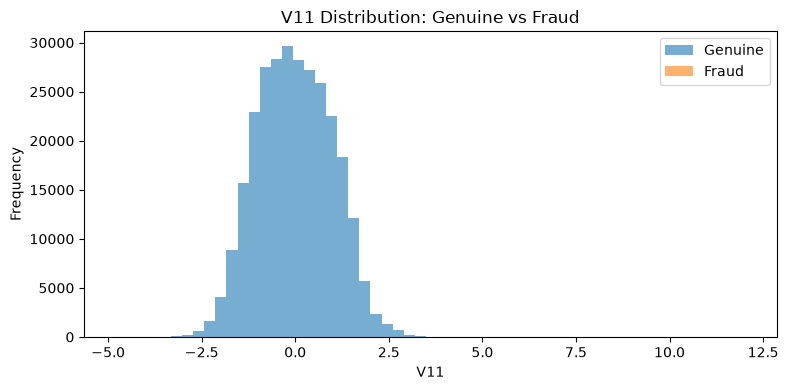

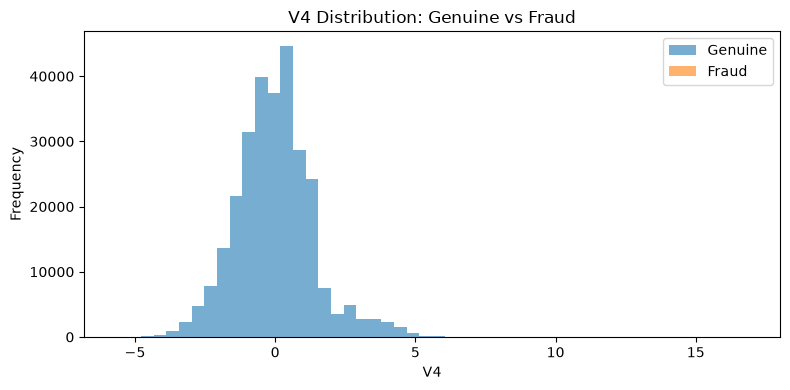

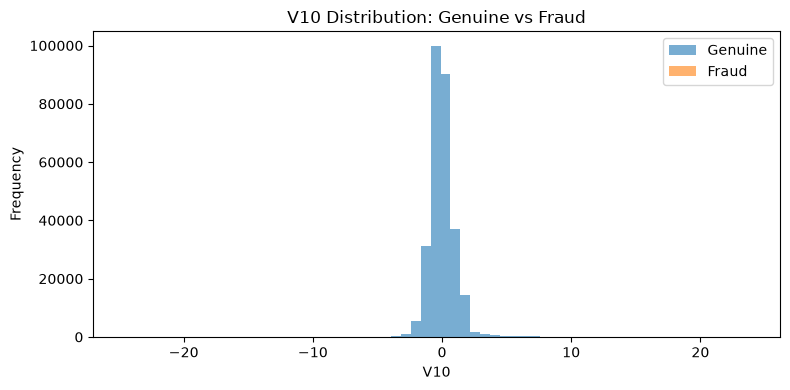

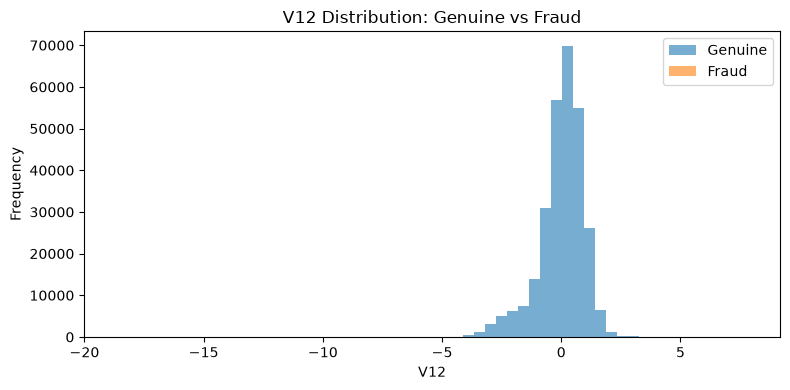

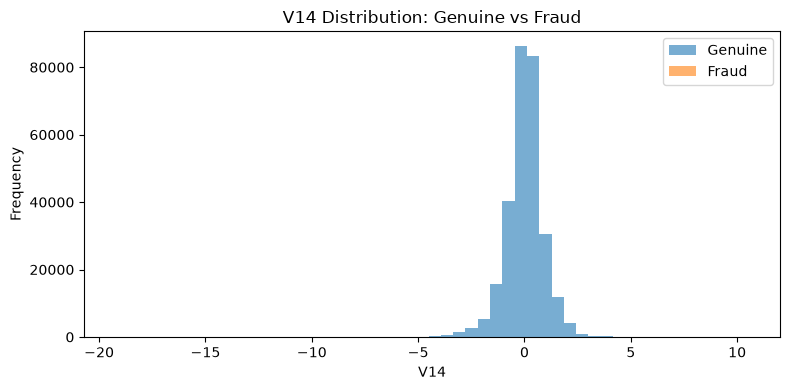

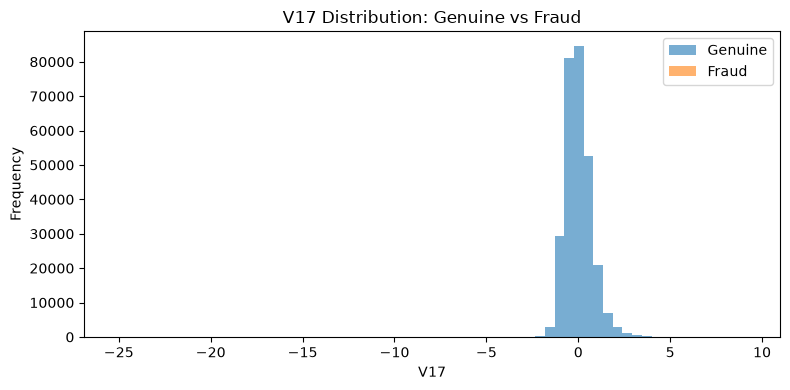

In [16]:
selected_features = ["V11", "V4", "V10", "V12", "V14", "V17"]

for feature in selected_features:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[df["Class"] == 0][feature],
        bins=50,
        alpha=0.6,
        label="Genuine"
    )

    plt.hist(
        df[df["Class"] == 1][feature],
        bins=50,
        alpha=0.6,
        label="Fraud"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"{feature} Distribution: Genuine vs Fraud")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. EDA Conclusion

The exploratory analysis confirms that this dataset represents a highly imbalanced fraud detection problem.

Key observations:

- The dataset contains 284,807 transactions across 31 columns.
- No missing values were identified.
- Duplicate records are present and require careful consideration during preprocessing.
- Fraudulent transactions represent a very small proportion of all transactions.
- Several anonymized features show different distributions between genuine and fraudulent transactions.
- Correlation analysis identified features with stronger relationships to the fraud target.
- Transaction amount and time provide additional behavioral information.

These findings provide the foundation for the feature engineering and machine learning stages of FraudShield X.

## 14. Feature Engineering

Feature engineering transforms the raw transaction data into additional signals that can help the fraud detection model identify unusual transaction behavior.

For FraudShield X, we will create:

- Transaction amount transformations
- Time-based features
- Transaction velocity indicators
- Behavioral anomaly indicators

In [17]:
df_model = df.copy()

print("Original shape:", df_model.shape)

Original shape: (284807, 31)


In [18]:
df_model["Amount_Log"] = np.log1p(df_model["Amount"])

print(df_model[["Amount", "Amount_Log"]].head())

   Amount  Amount_Log
0  149.62    5.014760
1    2.69    1.305626
2  378.66    5.939276
3  123.50    4.824306
4   69.99    4.262539


In [19]:
SECONDS_PER_DAY = 86400

df_model["Time_Hours"] = (df_model["Time"] % SECONDS_PER_DAY) / 3600

df_model["Time_Sin"] = np.sin(
    2 * np.pi * df_model["Time_Hours"] / 24
)

df_model["Time_Cos"] = np.cos(
    2 * np.pi * df_model["Time_Hours"] / 24
)

df_model[[
    "Time",
    "Time_Hours",
    "Time_Sin",
    "Time_Cos"
]].head()

,Time,Time_Hours,Time_Sin,Time_Cos
0,0.0,0.000000,0.000000,1.0
1,0.0,0.000000,0.000000,1.0
2,1.0,0.000278,0.000073,1.0
3,1.0,0.000278,0.000073,1.0
4,2.0,0.000556,0.000145,1.0


In [20]:
amount_mean = df_model["Amount"].mean()
amount_std = df_model["Amount"].std()

df_model["Amount_ZScore"] = (
    (df_model["Amount"] - amount_mean) / amount_std
)

df_model["Amount_Anomaly"] = (
    df_model["Amount_ZScore"].abs() > 3
).astype(int)

print(
    "Amount anomalies:",
    df_model["Amount_Anomaly"].sum()
)

Amount anomalies: 4076


In [21]:
new_features = [
    "Amount_Log",
    "Time_Hours",
    "Time_Sin",
    "Time_Cos",
    "Amount_ZScore",
    "Amount_Anomaly"
]

df_model[new_features].head()

,Amount_Log,Time_Hours,Time_Sin,Time_Cos,Amount_ZScore,Amount_Anomaly
0,5.014760,0.000000,0.000000,1.0,0.244964,0
1,1.305626,0.000000,0.000000,1.0,-0.342474,0
2,5.939276,0.000278,0.000073,1.0,1.160684,0
3,4.824306,0.000278,0.000073,1.0,0.140534,0
4,4.262539,0.000556,0.000145,1.0,-0.073403,0


## 15. Transaction Velocity Features

Fraudulent activity can sometimes involve multiple transactions within a short period of time.

To capture this behavior, we create transaction velocity features based on the temporal distribution of transactions.


In [22]:
df_model = df_model.sort_values("Time").reset_index(drop=True)

df_model["Time_Diff"] = df_model["Time"].diff().fillna(0)

print(df_model["Time_Diff"].describe())

count    284807.000000
mean          0.606699
std           1.053380
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          32.000000
Name: Time_Diff, dtype: float64


In [23]:
df_model["Rapid_Transaction"] = (
    (df_model["Time_Diff"] <= 10).astype(int)
)

print(
    "Rapid transactions:",
    df_model["Rapid_Transaction"].sum()
)

Rapid transactions: 284454


In [24]:
velocity_analysis = df_model.groupby("Class")[
    "Rapid_Transaction"
].agg(["count", "sum", "mean"])

velocity_analysis

,count,sum,mean
Class,,,
0,284315,283964,0.998765
1,492,490,0.995935


## 16. Engineered Feature Summary

FraudShield X now includes additional behavioral features derived from the original transaction data.

### Engineered Features

- Amount_Log
- Amount_ZScore
- Amount_Anomaly
- Time_Hours
- Time_Sin
- Time_Cos
- Time_Diff
- Rapid_Transaction

These features provide the machine learning model with additional information about transaction magnitude, temporal behavior, and potentially suspicious transaction velocity.

In [25]:
engineered_features = [
    "Amount_Log",
    "Amount_ZScore",
    "Amount_Anomaly",
    "Time_Hours",
    "Time_Sin",
    "Time_Cos",
    "Time_Diff",
    "Rapid_Transaction"
]

print("Engineered features:")
for feature in engineered_features:
    print("✓", feature)

Engineered features:
✓ Amount_Log
✓ Amount_ZScore
✓ Amount_Anomaly
✓ Time_Hours
✓ Time_Sin
✓ Time_Cos
✓ Time_Diff
✓ Rapid_Transaction


## 17. Data Preprocessing

Before training the fraud detection model, the dataset is prepared by separating the target variable from the input features.

The data will then be divided into training and testing sets using stratified sampling to preserve the fraud-to-genuine transaction ratio.

In [30]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Class"])
y = df_model["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 38)
Target shape: (284807,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining fraud rate:")
print(y_train.mean())

print("\nTesting fraud rate:")
print(y_test.mean())

Training samples: 227845
Testing samples: 56962

Training fraud rate:
0.001729245759178389

Testing fraud rate:
0.0017204452090867595


### Why Stratified Splitting?

Fraudulent transactions are extremely rare compared with genuine transactions.

Stratified splitting ensures that both the training and testing datasets maintain approximately the same proportion of fraudulent transactions as the original dataset.

## 18. Feature Scaling

The transaction features have different numerical ranges. Standardization is applied to numerical features so that they have a comparable scale.

To prevent data leakage, the scaler is fitted only on the training dataset and then applied to both training and testing data.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (227845, 38)
Testing data shape: (56962, 38)


## 19. Baseline Model — Logistic Regression

Logistic Regression is used as the first baseline model for FraudShield X.

The baseline provides a reference point against which more advanced fraud detection models can be compared.

Because the dataset is highly imbalanced, model performance will be evaluated using Precision, Recall, F1-Score, ROC-AUC, and Average Precision rather than accuracy alone.

In [33]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [34]:
y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [35]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9736    0.9866     56864
           1     0.0566    0.9184    0.1066        98

    accuracy                         0.9735     56962
   macro avg     0.5282    0.9460    0.5466     56962
weighted avg     0.9982    0.9735    0.9850     56962

ROC-AUC: 0.975
PR-AUC: 0.7211

Confusion Matrix:
[[55363  1501]
 [    8    90]]


## 20. Advanced Model — Random Forest

Random Forest is evaluated as a non-linear ensemble model to determine whether it can improve fraud detection performance compared with the Logistic Regression baseline.

The model will be evaluated using fraud-class Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [38]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9995    0.9996     56864
           1     0.7387    0.8367    0.7847        98

    accuracy                         0.9992     56962
   macro avg     0.8692    0.9181    0.8921     56962
weighted avg     0.9993    0.9992    0.9992     56962

ROC-AUC: 0.9869
PR-AUC: 0.854

Confusion Matrix:
[[56835    29]
 [   16    82]]


## 21. Fraud Detection Threshold Optimization

The default classification threshold of 0.50 is not always optimal for fraud detection.

Different probability thresholds are evaluated to understand the trade-off between fraud recall and false-positive rate.

This allows FraudShield X to select a threshold based on the desired balance between fraud detection and customer disruption.

In [39]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.1319,0.9082,0.2303
1,0.15,0.2551,0.8980,0.3973
2,0.20,0.3607,0.8980,0.5146
3,0.25,0.4757,0.8980,0.6219
4,0.30,0.5337,0.8878,0.6667
5,0.35,0.6159,0.8673,0.7203
6,0.40,0.6641,0.8673,0.7522
7,0.45,0.6975,0.8469,0.7650
8,0.50,0.7387,0.8367,0.7847
9,0.55,0.8100,0.8265,0.8182


In [40]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Best threshold based on F1-score:", best_threshold)

Best threshold based on F1-score: 0.7


### Threshold Selection

The threshold with the highest F1-score provides a balanced trade-off between fraud precision and recall.

This threshold will be evaluated further before being selected as the operating threshold for FraudShield X.

## 22. Final Threshold Evaluation

Based on threshold optimization, a probability threshold of 0.70 produced the highest F1-score on the evaluation set.

We now evaluate FraudShield X using this selected threshold and compare its performance with the default 0.50 threshold.

In [41]:
final_threshold = 0.70

final_pred = (rf_prob >= final_threshold).astype(int)

print("Final Threshold:", final_threshold)

print("\nClassification Report:")
print(classification_report(y_test, final_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Threshold: 0.7

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56864
           1     0.9048    0.7755    0.8352        98

    accuracy                         0.9995     56962
   macro avg     0.9522    0.8877    0.9175     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9869
PR-AUC: 0.854

Confusion Matrix:
[[56856     8]
 [   22    76]]


In [42]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_pred
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56856
False Positives: 8
False Negatives: 22
True Positives  : 76


### Business Interpretation

FraudShield X uses the selected probability threshold to balance fraud detection against false alarms.

In a real financial system, the threshold can be adjusted according to business requirements. A lower threshold may detect more fraudulent transactions but generate more false alerts, while a higher threshold may reduce false alerts but potentially miss more fraud.

## 23. Random Forest Feature Importance

Random Forest provides feature importance scores that help identify which transaction features contributed most to the model's predictions.

These scores are used for model interpretation and do not imply causation.

In [43]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
display(feature_importance.head(15))

Top 15 Important Features:


V14    0.178511
V10    0.127277
V11    0.108474
V12    0.100343
V4     0.099970
V3     0.051272
V17    0.051010
V16    0.040401
V7     0.024769
V2     0.019482
V18    0.018970
V21    0.013919
V9     0.012627
V20    0.011622
V1     0.010326
dtype: float64

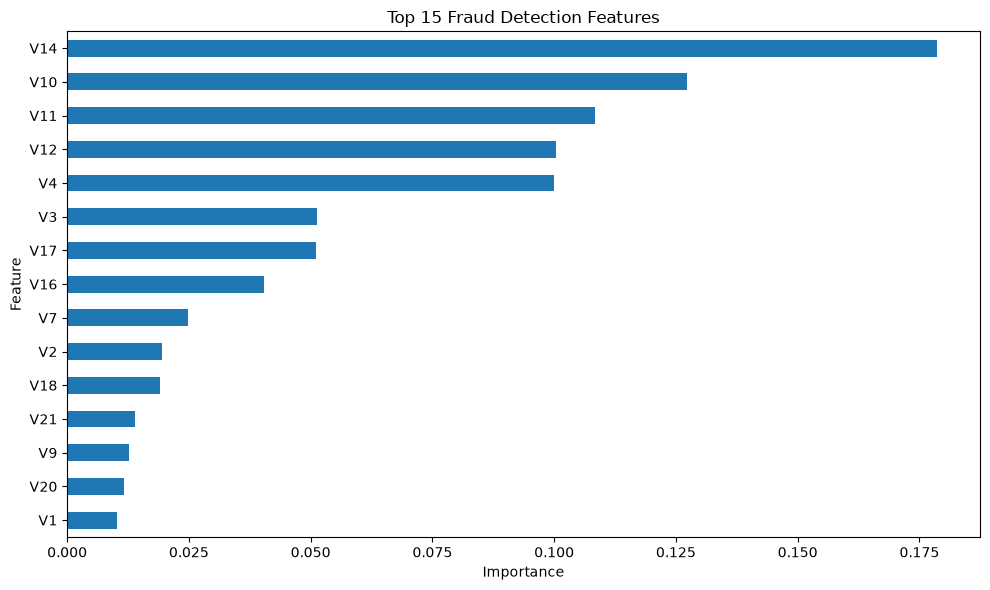

In [44]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Fraud Detection Features")
plt.tight_layout()
plt.show()

## 24. Model Performance Comparison

FraudShield X evaluates multiple machine learning approaches to identify the model that provides the best balance between fraud detection and false-positive control.

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.0566,0.9184,0.1066,0.9750,0.7211
1,Random Forest,0.7387,0.8367,0.7847,0.9869,0.8540


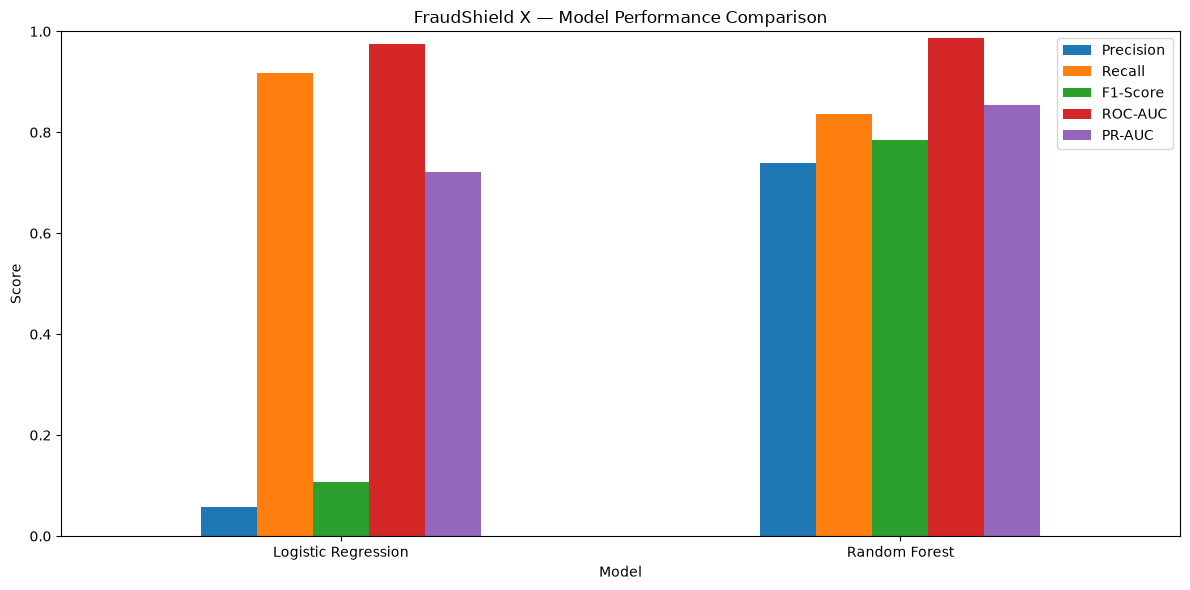

In [47]:
comparison.set_index("Model")[[
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("FraudShield X — Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Model Selection

Random Forest demonstrated stronger overall performance than the Logistic Regression baseline, particularly in fraud-class precision, F1-score, ROC-AUC, and PR-AUC.

The Random Forest model is therefore selected as the current machine learning model for FraudShield X.

Threshold optimization will be used to control the trade-off between fraud detection and false-positive alerts.

## 25. Saving the Fraud Detection Model

The trained Random Forest model, feature scaler, and selected decision threshold are saved so that they can be reused by the FraudShield X prediction API without retraining the model.

In [48]:
import os
import joblib

MODEL_DIR = "../../models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(rf_model, f"{MODEL_DIR}/fraudshield_rf_model.joblib")
joblib.dump(scaler, f"{MODEL_DIR}/fraudshield_scaler.joblib")

with open(f"{MODEL_DIR}/threshold.txt", "w") as f:
    f.write(str(final_threshold))

print("FraudShield X model saved successfully!")
print("Model:", f"{MODEL_DIR}/fraudshield_rf_model.joblib")
print("Scaler:", f"{MODEL_DIR}/fraudshield_scaler.joblib")
print("Threshold:", final_threshold)

FraudShield X model saved successfully!
Model: ../../models/fraudshield_rf_model.joblib
Scaler: ../../models/fraudshield_scaler.joblib
Threshold: 0.7
